### 1. Library Imports

Importing all required libraries upfront:
- **pandas / numpy** — data manipulation and numerical operations
- **matplotlib / seaborn** — visualization
- **sklearn** — preprocessing, model training, evaluation, and hyperparameter tuning
- **statsmodels** — classical time series models (Holt-Winters, SARIMA, ADF test)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-whitegrid')
print("** All libraries loaded **")

** All libraries loaded **


### 2. Load Dataset

Loading the Tesla deliveries CSV into a pandas DataFrame. The dataset contains **2640 rows × 12 columns**, representing monthly Tesla delivery and production figures broken down by **Region** (4 values) and **Model** (5 values) from 2015–2025. Each row is one (Year, Month, Region, Model) combination — making this **panel data**, not a simple time series.

In [19]:
df = pd.read_csv("data/tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(5)

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


### 3. Initial Data Inspection

Examining data types, unique values for categorical columns, and missing value counts. Key observations:
- All 12 columns are fully populated — **no missing values**
- Categoricals: `Region` (4 unique), `Model` (5 unique), `Source_Type` (3 unique — Official / Interpolated / Estimated)
- Numerics: deliveries, production, price, battery capacity, range, CO₂ saved, charging stations
- **regression target** is `Avg_Price_USD` (the "price data" in the assignment)

In [20]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Unique Values (Categoricals) ===")
for col in ['Region', 'Model', 'Source_Type']:
    print(f"  {col}: {df[col].unique().tolist()}")

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Data Types ===
Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

=== Unique Values (Categoricals) ===
  Region: ['Europe', 'Asia', 'North America', 'Middle East']
  Model: ['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
  Source_Type: ['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)']

=== Missing Values ===
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations     

### 4. Preprocessing — Column Standardization & Date Construction

1. **Standardising column names** — lowercase with underscores for consistent referencing throughout the notebook
2. **Constructing a `date` column** from `Year` and `Month` — this enables chronological sorting, time-based splits, and time series aggregation later
3. **Drop `Source_Type`** — this column describes how the value was obtained, not a meaningful predictive feature

In [21]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Create datetime column
df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))
df = df.sort_values('date').reset_index(drop=True)

# Drop Source_Type — it's a data provenance note, not a feature
df.drop(columns=['source_type'], inplace=True)

print("Cleaned columns:", df.columns.tolist())
print("Date range:", df['date'].min().date(), "→", df['date'].max().date())
df.head()

Cleaned columns: ['year', 'month', 'region', 'model', 'estimated_deliveries', 'production_units', 'avg_price_usd', 'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'charging_stations', 'date']
Date range: 2015-01-01 → 2025-12-01


,year,month,region,model,estimated_deliveries,production_units,avg_price_usd,battery_capacity_kwh,range_km,co2_saved_tons,charging_stations,date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,12626,2015-01-01


### 5. Preprocessing — Categorical Encoding

Encoding `Region` and `Model` features:
- **Label Encoding** — assigns an integer to each category (compact, useful for tree-based models)
- **One-Hot Encoding** — creates a binary column per category (avoids implying ordinal relationships, better for linear models)

In [22]:
le_region = LabelEncoder()
le_model  = LabelEncoder()

df['region_enc'] = le_region.fit_transform(df['region'])
df['model_enc']  = le_model.fit_transform(df['model'])

# One-hot encode for better ML performance
region_dummies = pd.get_dummies(df['region'], prefix='region')
model_dummies  = pd.get_dummies(df['model'],  prefix='model')

df = pd.concat([df, region_dummies, model_dummies], axis=1)

print("Label encoded Region:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Label encoded Model:", dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))
print("\nDataframe shape after encoding:", df.shape)
df.head(3)

Label encoded Region: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Label encoded Model: {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}

Dataframe shape after encoding: (2640, 23)


,year,month,region,model,estimated_deliveries,production_units,avg_price_usd,battery_capacity_kwh,range_km,co2_saved_tons,...,model_enc,region_Asia,region_Europe,region_Middle East,region_North America,model_Cybertruck,model_Model 3,model_Model S,model_Model X,model_Model Y
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,...,4,True,False,False,False,False,False,False,False,True
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,...,1,False,False,True,False,False,True,False,False,False
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,...,0,False,False,True,False,True,False,False,False,False


### 6. Exploratory Data Analysis (EDA)

- **Price trends by model over time** — how each Tesla model's avg price evolved from 2015–2025; reveals pricing strategy shifts
- **Deliveries by region** — which geography contributes most to global volume
- **Price distribution by model (box plots)** — median, spread, and outliers per model; higher-end models (Model X, Cybertruck) should show higher medians
- **Correlation heatmap** — quantifies linear relationships between numeric features and the target (`avg_price_usd`); `battery_capacity_kwh` and `range_km` are expected to correlate strongly with price
- **Global delivery + production trends** — aggregate view across all regions and models to observe Tesla's growth trajectory

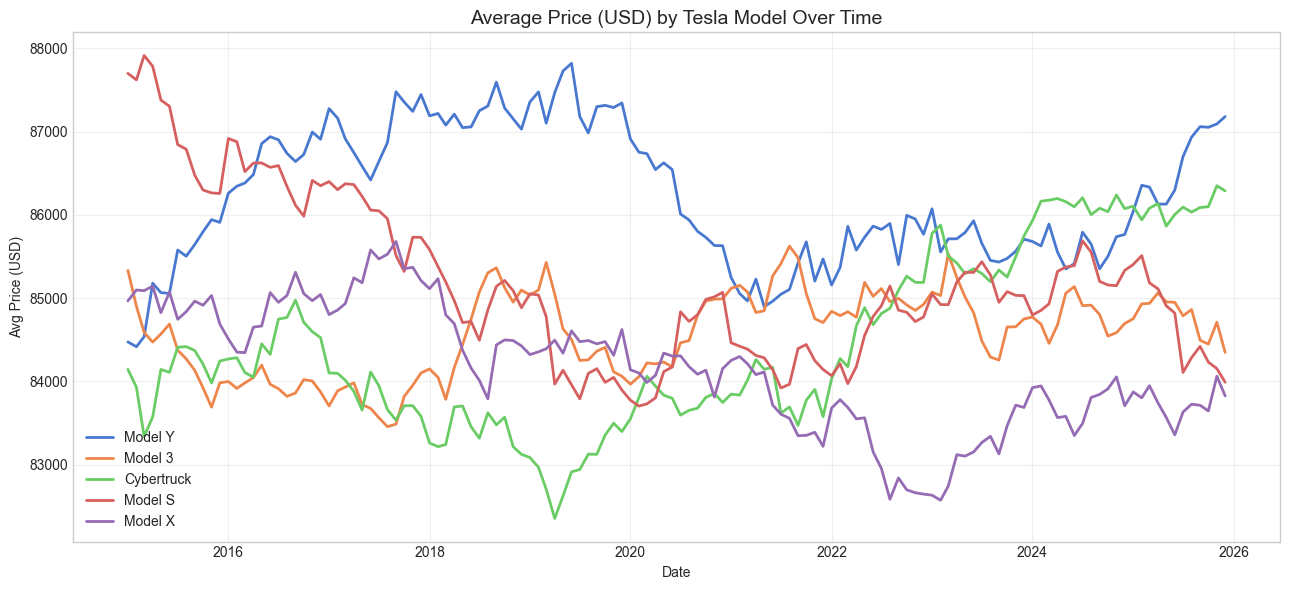

In [41]:
price_by_model = df.groupby(['date', 'model'])['avg_price_usd'].mean().reset_index()

plt.figure(figsize=(13, 6))
for model in df['model'].unique():
    subset = price_by_model[price_by_model['model'] == model].sort_values('date')

    # Smooth the line using a rolling average
    smooth_prices = subset['avg_price_usd'].rolling(window=60, center=True, min_periods=1).mean()
    plt.plot(subset['date'], smooth_prices, label=model, linewidth=2)

plt.title("Average Price (USD) by Tesla Model Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Avg Price (USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

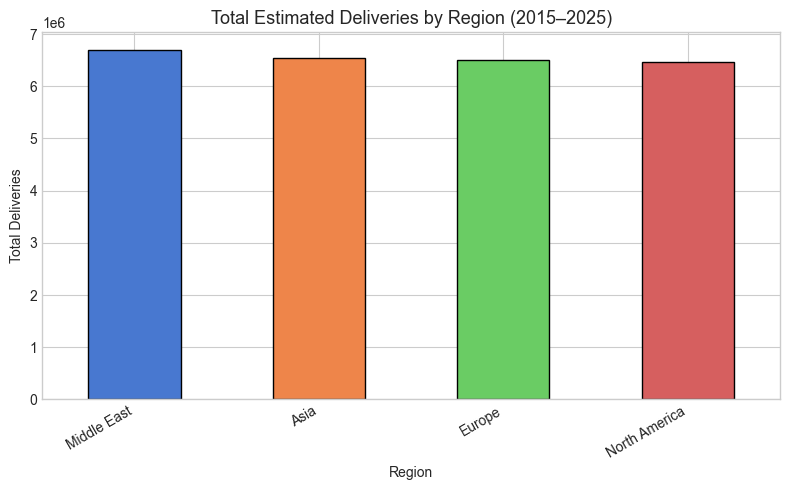

In [42]:
region_del = df.groupby('region')['estimated_deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_del.plot(kind='bar', color=sns.color_palette("muted", 4), edgecolor='black')
plt.title("Total Estimated Deliveries by Region (2015–2025)", fontsize=13)
plt.ylabel("Total Deliveries")
plt.xlabel("Region")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

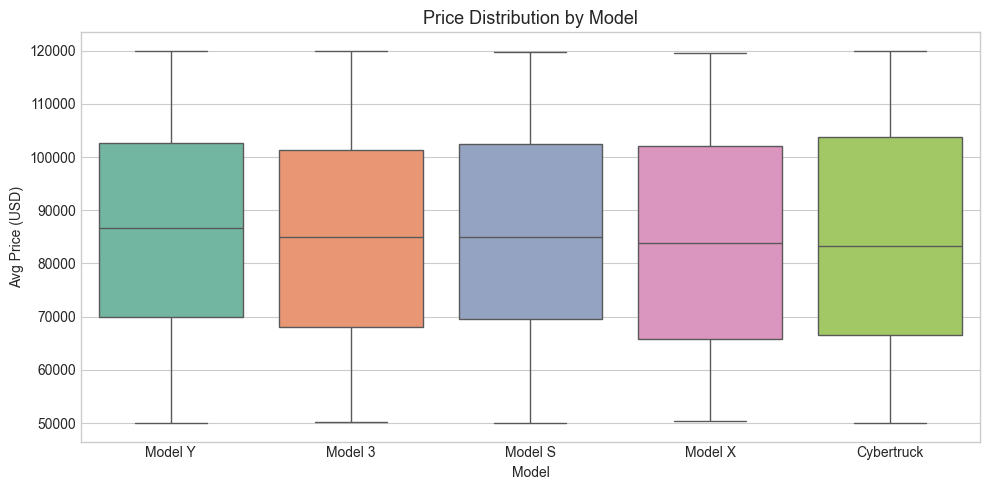

In [43]:
plt.figure(figsize=(10, 5))
order = df.groupby('model')['avg_price_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='model', y='avg_price_usd', order=order, palette='Set2')
plt.title("Price Distribution by Model", fontsize=13)
plt.xlabel("Model")
plt.ylabel("Avg Price (USD)")
plt.tight_layout()
plt.show()

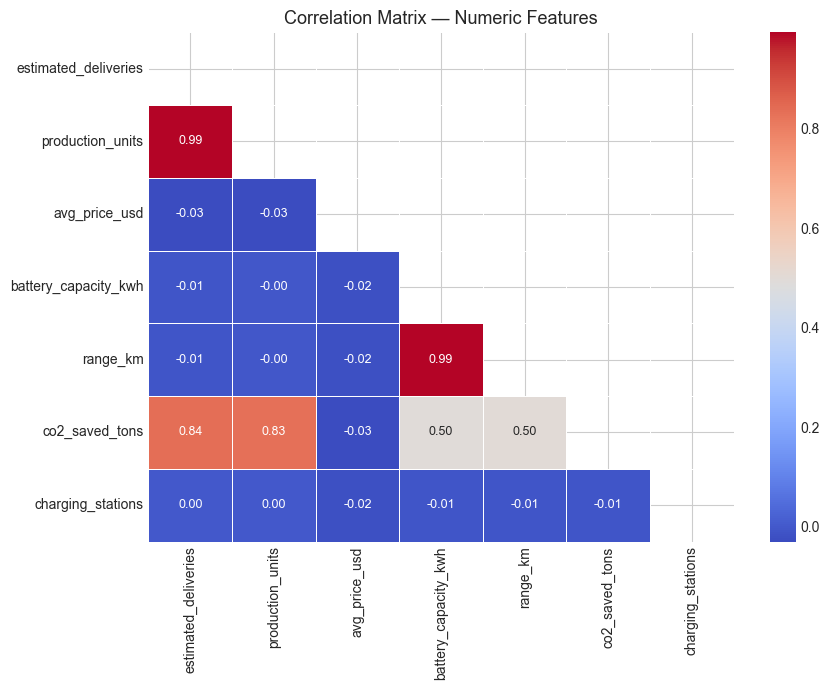

In [44]:
num_cols = ['estimated_deliveries', 'production_units', 'avg_price_usd',
            'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'charging_stations']

plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={"size": 9})
plt.title("Correlation Matrix — Numeric Features", fontsize=13)
plt.tight_layout()
plt.show()

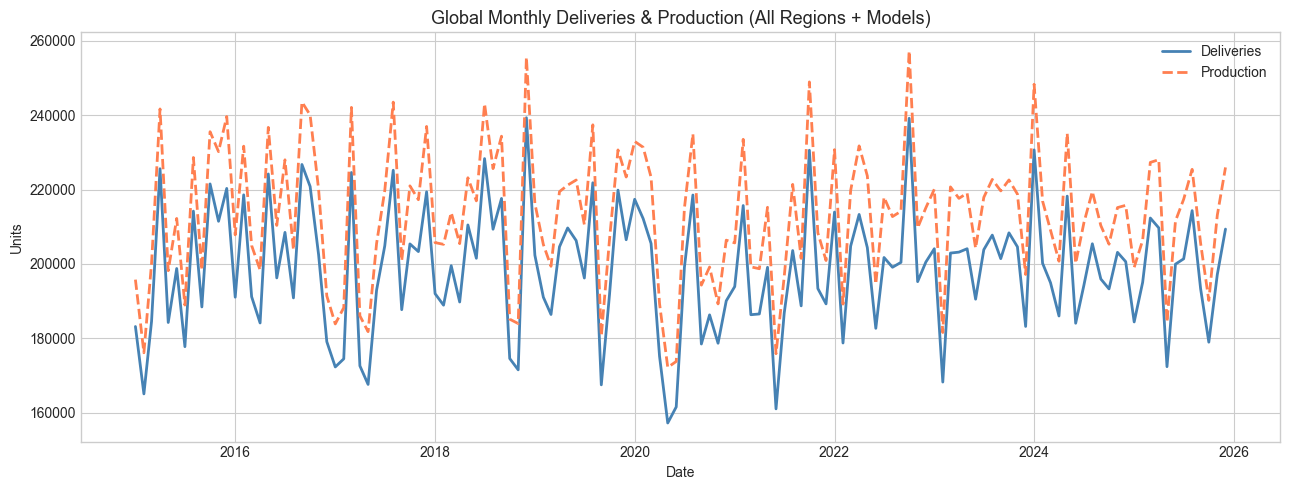

In [45]:
monthly_agg = df.groupby('date')[['estimated_deliveries', 'production_units']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(monthly_agg['date'], monthly_agg['estimated_deliveries'],
         color='steelblue', linewidth=2, label='Deliveries')
ax1.plot(monthly_agg['date'], monthly_agg['production_units'],
         color='coral', linewidth=2, linestyle='--', label='Production')
ax1.set_title("Global Monthly Deliveries & Production (All Regions + Models)", fontsize=13)
ax1.set_ylabel("Units")
ax1.set_xlabel("Date")
ax1.legend()
plt.tight_layout()
plt.show()